# 🌿 AgroVision Plant Disease Detection using EfficientNet

Dataset → Cleaning → Preprocessing → Augmentation → EfficientNet Training → Evaluation → Prediction Pipeline → Fine-Tuning

---
## 🔁 Resumable Training Strategy
| Session | Epochs | Action |
|---------|--------|--------|
| Session 1 | 0 → 3 | Train fresh, save to Drive |
| Session 2 | 3 → 6 | Load from Drive, train 3 more, save |
| Session 3 | 6 → 8 | Load from Drive, train 2 more, save |
| ... | ... | Keep going until 8 total epochs |

> ✅ **History is accumulated across ALL sessions** — graphs always show full training from epoch 0!

## 📦 Step 1: One-Time Setup — Kaggle API & Dataset Download
> ⚠️ Only run this section ONCE to download and extract the dataset.

In [4]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from google.colab import files
print("📤 Upload kaggle.json")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!apt-get install -y p7zip-full

ZIP_PATH = "/content/dataset.zip"
EXTRACT_PATH = "/content/dataset"

print("\n⬇️ Downloading dataset...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p /content
!mv /content/new-plant-diseases-dataset.zip "{ZIP_PATH}"

if os.path.exists(EXTRACT_PATH):
    !rm -rf "{EXTRACT_PATH}"
os.makedirs(EXTRACT_PATH, exist_ok=True)

print("\n📦 Extracting dataset...")
!7z x "{ZIP_PATH}" -o"{EXTRACT_PATH}"

print("\n✅ DONE!")
print(os.listdir(EXTRACT_PATH))

📤 Upload kaggle.json


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 100 not upgraded.

⬇️ Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:12<00:00, 224MB/s]


📦 Extracting dataset...

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 2897709187 bytes (2764 MiB)

Extracting archive: /content/dataset.zip
  2% 4096 Open               90% 159744 Open                --
Path = /content/dataset.zip
Type = zip
Physical Size = 2897709187
64

## 📊 Step 2: Data Understanding

In [5]:
import os

dataset_path = "/content/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

def count_images(folder):
    total = 0
    per_class = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        per_class[cls] = len(images)
        total += len(images)
    return total, per_class

train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")

train_total, train_counts = count_images(train_path)
valid_total, valid_counts = count_images(valid_path)
classes = list(train_counts.keys())

print("📊 DATASET SUMMARY")
print("Total classes:", len(train_counts))
print("Train images:", train_total)
print("Validation images:", valid_total)

📊 DATASET SUMMARY
Total classes: 38
Train images: 70295
Validation images: 17572


In [7]:
import pandas as pd

df = pd.DataFrame({"Train": train_counts, "Validation": valid_counts})
df = df.fillna(0).astype(int)
df["Total"] = df["Train"] + df["Validation"]
df = df.sort_values(by="Total", ascending=False).reset_index().rename(columns={"index": "Class"})
df.head(10)

,Class,Train,Validation,Total
0,Soybean___healthy,2022,505,2527
1,Apple___Apple_scab,2016,504,2520
2,Orange___Haunglongbing_(Citrus_greening),2010,503,2513
3,Apple___healthy,2008,502,2510
4,"Pepper,_bell___healthy",1988,497,2485
5,Apple___Black_rot,1987,497,2484
6,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961,490,2451
7,Potato___Late_blight,1939,485,2424
8,Potato___Early_blight,1939,485,2424
9,Tomato___healthy,1926,481,2407


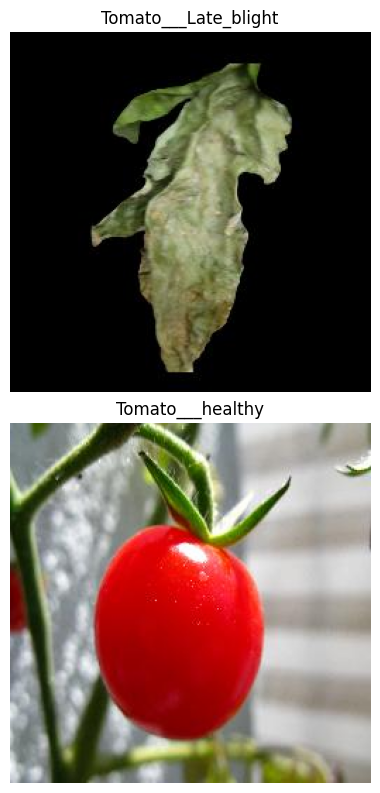

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(12, 8))
for i in range(6):
    cls = random.choice(classes)
    cls_path = os.path.join(train_path, cls)
    imgs = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not imgs:
        continue
    try:
        with Image.open(os.path.join(cls_path, random.choice(imgs))) as img:
            plt.subplot(2, 3, i + 1)
            plt.imshow(img)
            plt.title(cls[:30])
            plt.axis("off")
    except:
        continue
plt.tight_layout()
plt.show()

## ✂️ Step 3: Dataset Splitting (Train / Valid / Test)

In [9]:
import os, shutil, random
from tqdm import tqdm

def split_dataset(dataset_path, output_path, train_ratio=0.8):
    random.seed(42)
    if os.path.exists(output_path):
        shutil.rmtree(output_path)
    os.makedirs(output_path, exist_ok=True)

    train_out = os.path.join(output_path, "train")
    valid_out = os.path.join(output_path, "valid")
    test_out  = os.path.join(output_path, "test")
    for p in [train_out, valid_out, test_out]:
        os.makedirs(p, exist_ok=True)

    train_src = os.path.join(dataset_path, "train")
    valid_src = os.path.join(dataset_path, "valid")

    for cls in tqdm(os.listdir(train_src), desc="Splitting train"):
        src_cls = os.path.join(train_src, cls)
        if not os.path.isdir(src_cls):
            continue
        images = [f for f in os.listdir(src_cls) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        split_idx = int(len(images) * train_ratio)
        os.makedirs(os.path.join(train_out, cls), exist_ok=True)
        os.makedirs(os.path.join(test_out, cls), exist_ok=True)
        for img in images[:split_idx]:
            shutil.copy2(os.path.join(src_cls, img), os.path.join(train_out, cls, img))
        for img in images[split_idx:]:
            shutil.copy2(os.path.join(src_cls, img), os.path.join(test_out, cls, img))

    for cls in tqdm(os.listdir(valid_src), desc="Copying validation"):
        src_cls = os.path.join(valid_src, cls)
        if not os.path.isdir(src_cls):
            continue
        dst_cls = os.path.join(valid_out, cls)
        os.makedirs(dst_cls, exist_ok=True)
        for img in os.listdir(src_cls):
            if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(os.path.join(src_cls, img), os.path.join(dst_cls, img))

    print("✅ Split complete!")

output_path = "/content/final_dataset"
split_dataset(dataset_path, output_path, train_ratio=0.8)

Copying validation: 100%|██████████| 38/38 [00:09<00:00,  4.00it/s]

✅ Split complete!


In [10]:
subset_path = "/content/final_dataset"
train_path = os.path.join(subset_path, "train")
valid_path = os.path.join(subset_path, "valid")
test_path  = os.path.join(subset_path, "test")

train_total, train_counts = count_images(train_path)
valid_total, valid_counts = count_images(valid_path)
test_total,  test_counts  = count_images(test_path)

print("📦 FINAL DATASET SUMMARY")
print("Total classes:", len(train_counts))
print("Train:", train_total, "| Valid:", valid_total, "| Test:", test_total)
print("Train/Test ratio:", round(train_total / (train_total + test_total), 2))

📦 FINAL DATASET SUMMARY
Total classes: 38
Train: 56219 | Valid: 17572 | Test: 14076
Train/Test ratio: 0.8


## 🧹 Step 4: Cleaning

In [11]:
from PIL import Image
from tqdm import tqdm

def remove_corrupted_images(folder):
    removed = 0
    image_paths = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(root, file))
    print(f"📊 Total images to check: {len(image_paths)}")
    for path in tqdm(image_paths, desc="Checking images"):
        try:
            with Image.open(path) as img:
                img.verify()
        except:
            os.remove(path)
            removed += 1
    print("✅ Done | Corrupted removed:", removed)

remove_corrupted_images("/content/final_dataset")

📊 Total images to check: 87867


Checking images: 100%|██████████| 87867/87867 [00:06<00:00, 12688.15it/s]

✅ Done | Corrupted removed: 0


In [12]:
valid_ext = (".jpg", ".jpeg", ".png")
removed = 0
file_paths = []
for root, _, files in os.walk("/content/final_dataset"):
    for file in files:
        file_paths.append(os.path.join(root, file))
print(f"📊 Total files found: {len(file_paths)}")
for path in tqdm(file_paths, desc="Cleaning non-image files"):
    if not path.lower().endswith(valid_ext):
        try:
            os.remove(path)
            removed += 1
        except:
            continue
print("✅ Done | Non-image files removed:", removed)

📊 Total files found: 87867


Cleaning non-image files: 100%|██████████| 87867/87867 [00:00<00:00, 2191504.39it/s]

✅ Done | Non-image files removed: 0


## ⚙️ Step 5: Imports & Config

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import json

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# ── Config ──────────────────────────────────────────────────
IMG_SIZE     = 224
BATCH_SIZE   = 32
TOTAL_EPOCHS = 8        # 🎯 final target — spread across all sessions

TRAIN_PATH = "/content/final_dataset/train"
VALID_PATH = "/content/final_dataset/valid"
TEST_PATH  = "/content/final_dataset/test"

# 💾 Google Drive — checkpoint folder
SAVE_DIR      = "/content/drive/MyDrive/agrovision_checkpoint"
WEIGHTS_FILE  = os.path.join(SAVE_DIR, "model.weights.h5")
EPOCH_FILE    = os.path.join(SAVE_DIR, "epochs_done.txt")
HISTORY_FILE  = os.path.join(SAVE_DIR, "training_history.json")  # 📊 persistent history matrix

print("✅ Config ready | TF version:", tf.__version__)

✅ Config ready | TF version: 2.20.0


## 📂 Step 6: Data Generators

In [14]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=40,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_gen = valid_datagen.flow_from_directory(
    VALID_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

print("Train batches:", len(train_gen))
print("Valid batches:", len(valid_gen))

Found 56219 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Train batches: 1757
Valid batches: 550


## 🧠 Step 7: Build Model

In [15]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(38, activation="softmax")   # 38 plant disease classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,392,393 (16.76 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 🔁 Step 8: Resumable Training with Persistent History Matrix

> **History is saved to Drive after every session.**  
> Graphs always show the full training curve from epoch 0 — not just the current session.

### How it works:
| Session | Set `EPOCHS_THIS_SESSION` to | Result |
|---------|-------------------------------|--------|
| Session 1 | `3` | Trains epochs 0–2, saves |
| Session 2 | `3` | Loads weights + history, trains epochs 3–5, saves |
| Session 3+ | any number | Keeps going from last saved point |

> 🔧 **Only change `EPOCHS_THIS_SESSION`** each session. Everything else is automatic.

In [16]:
# ============================================================
# 🔁 RESUMABLE TRAINING — WITH PERSISTENT HISTORY MATRIX
# ============================================================

from google.colab import drive
from keras.callbacks import ModelCheckpoint, EarlyStopping

drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Load or initialize persistent history matrix ──────────────
if os.path.exists(HISTORY_FILE):
    with open(HISTORY_FILE, "r") as f:
        all_history = json.load(f)
    print(f"📊 Loaded history: {len(all_history['accuracy'])} epochs recorded")
else:
    all_history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    print("🆕 No history found — starting fresh history matrix")

# ── Callbacks ─────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    WEIGHTS_FILE,
    save_weights_only=True,
    save_freq='epoch',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

# ── Load previous weights & epoch count ───────────────────────
if os.path.exists(EPOCH_FILE) and os.path.exists(WEIGHTS_FILE):
    with open(EPOCH_FILE) as f:
        epochs_done = int(f.read().strip())
    model.load_weights(WEIGHTS_FILE)
    print(f"🔄 Checkpoint loaded! Completed: {epochs_done} epochs")
else:
    epochs_done = 0
    print("🆕 Starting fresh from epoch 0")

# ── Auto-calculate remaining epochs (no manual change needed!) ─
EPOCHS_PER_SESSION = 3
remaining = TOTAL_EPOCHS - epochs_done
EPOCHS_THIS_SESSION = min(EPOCHS_PER_SESSION, remaining)

print(f"▶️  This session: {epochs_done} → {epochs_done + EPOCHS_THIS_SESSION}")

# ── Guard against over-training ───────────────────────────────
if epochs_done >= TOTAL_EPOCHS:
    print(f"🎉 Already completed all {TOTAL_EPOCHS} epochs!")
else:
    end_epoch = epochs_done + EPOCHS_THIS_SESSION

    # ── Train ──────────────────────────────────────────────────
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=end_epoch,
        initial_epoch=epochs_done,
        callbacks=[checkpoint_cb, early_stop]
    )

    # ── Append this session's metrics to the persistent matrix ─
    for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        all_history[key].extend(history.history[key])

    # ── Save history matrix to Drive ───────────────────────────
    with open(HISTORY_FILE, "w") as f:
        json.dump(all_history, f)
    print(f"📊 History matrix saved → {HISTORY_FILE}")

    # ── Save epoch progress ────────────────────────────────────
    actual_end = epochs_done + len(history.history['accuracy'])
    with open(EPOCH_FILE, "w") as f:
        f.write(str(actual_end))

    print(f"\n✅ Session complete!")
    print(f"💾 Weights saved   → {WEIGHTS_FILE}")
    print(f"📈 Total done      : {actual_end}/{TOTAL_EPOCHS}")
    print(f"📉 Remaining       : {TOTAL_EPOCHS - actual_end}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Loaded history: 8 epochs recorded
🔄 Checkpoint loaded! Completed: 8 epochs
▶️  This session: 8 → 8
🎉 Already completed all 8 epochs!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 📈 Step 9: Plot Full Training History (All Sessions)
> Shows accuracy & loss from **epoch 0 to current** — uses the persistent history matrix from Drive.

/tmp/ipykernel_3023/2990745435.py:34: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/2990745435.py:34: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/2990745435.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
/tmp/ipykernel_3023/2990745435.py:35: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)


📊 Plotting full history: 8 epochs total


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


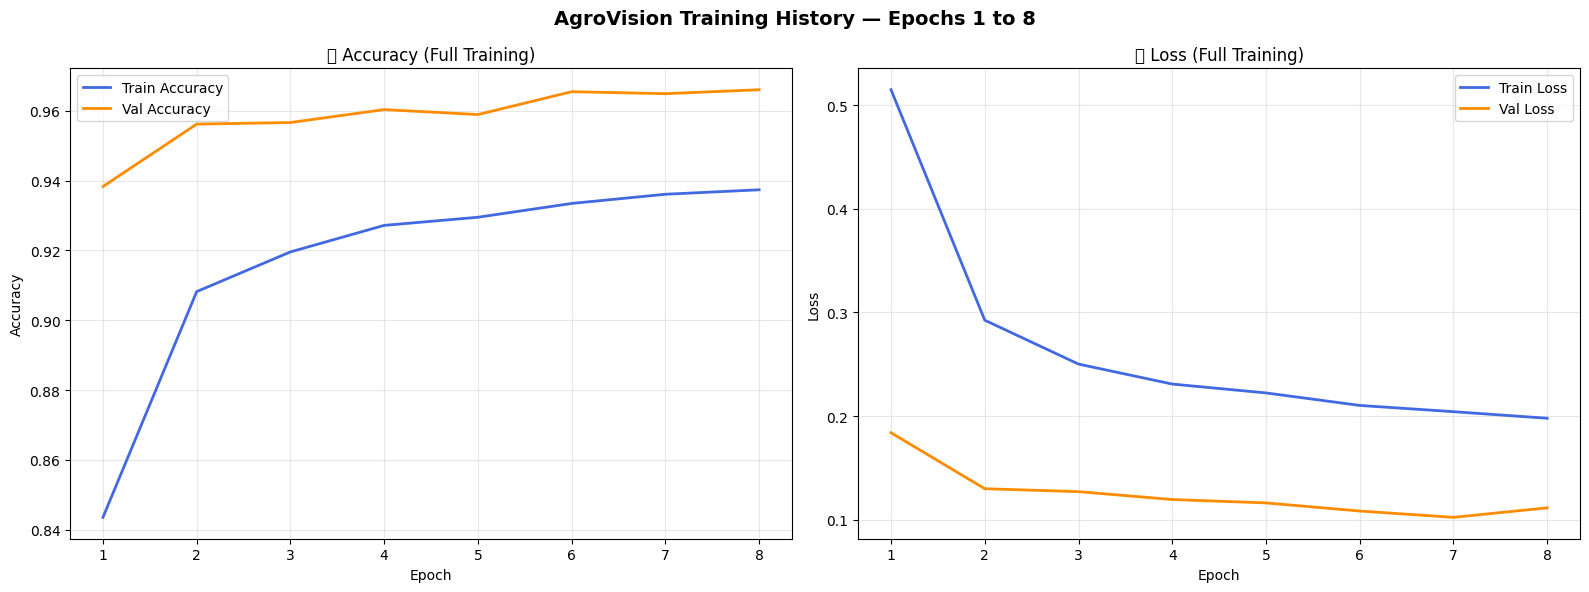

✅ Graph saved to Drive → training_curves.png


In [17]:
# ── Load full accumulated history from Drive ───────────────────
with open(HISTORY_FILE, "r") as f:
    all_history = json.load(f)

total_epochs_trained = len(all_history['accuracy'])
epoch_range = range(1, total_epochs_trained + 1)

print(f"📊 Plotting full history: {total_epochs_trained} epochs total")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"AgroVision Training History — Epochs 1 to {total_epochs_trained}",
             fontsize=14, fontweight='bold')

# ── Accuracy plot ──────────────────────────────────────────────
axes[0].plot(epoch_range, all_history['accuracy'],    label='Train Accuracy',      color='royalblue',  linewidth=2)
axes[0].plot(epoch_range, all_history['val_accuracy'], label='Val Accuracy',       color='darkorange', linewidth=2)
axes[0].set_title('📈 Accuracy (Full Training)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(list(epoch_range))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss plot ──────────────────────────────────────────────────
axes[1].plot(epoch_range, all_history['loss'],     label='Train Loss',  color='royalblue',  linewidth=2)
axes[1].plot(epoch_range, all_history['val_loss'], label='Val Loss',    color='darkorange', linewidth=2)
axes[1].set_title('📉 Loss (Full Training)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(list(epoch_range))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()
print("✅ Graph saved to Drive → training_curves.png")

## ✅ Step 10: Evaluation

In [18]:
loss, acc = model.evaluate(valid_gen)
print(f"Validation Accuracy : {acc*100:.2f}%")
print(f"Validation Loss     : {loss:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9660 - loss: 0.1115
Validation Accuracy : 96.60%
Validation Loss     : 0.1115


## 🔢 Step 11: Confusion Matrix

550/550 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step


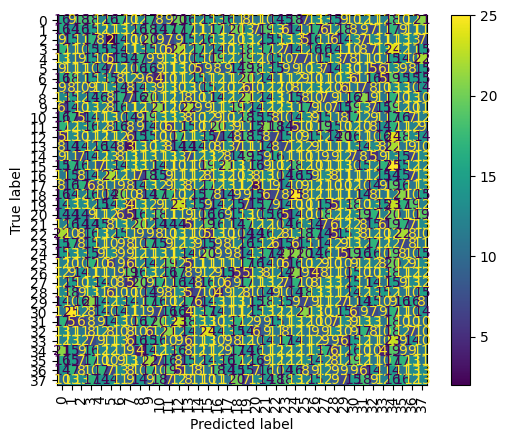

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(valid_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = valid_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.show()

## 🖼️ Step 12: Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Min: 0.0 Max: 255.0


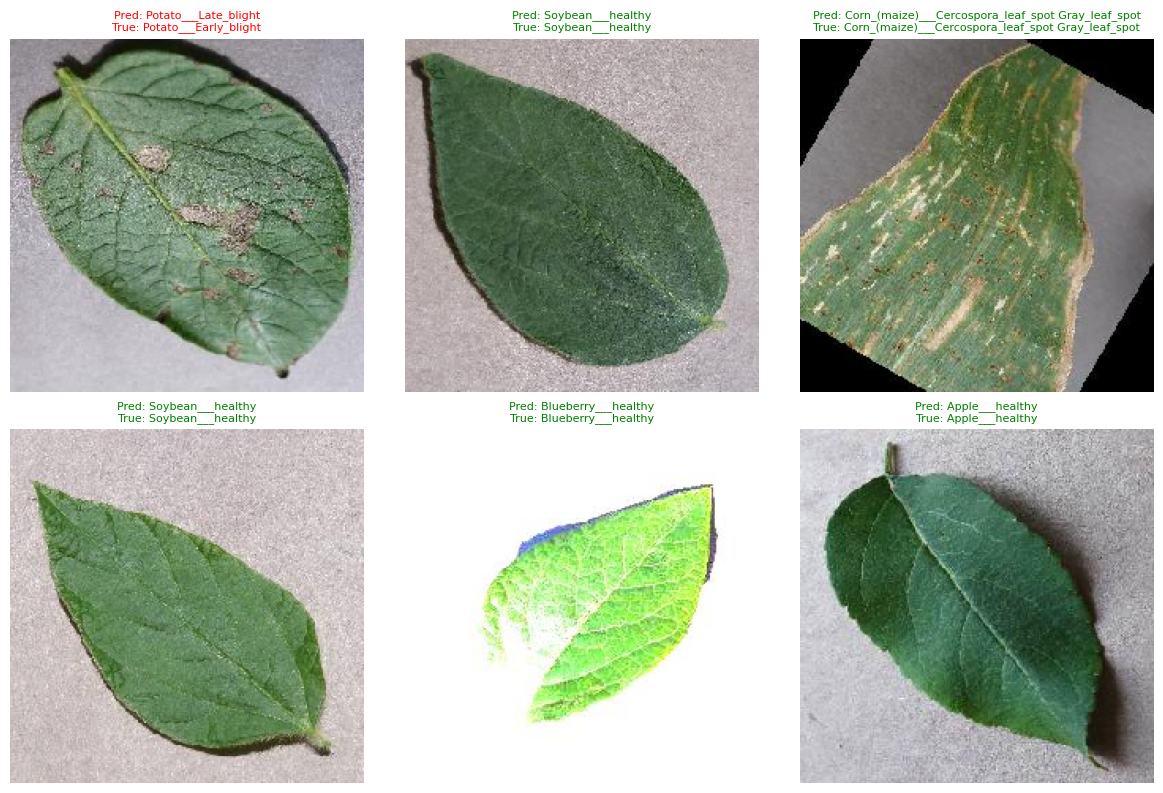

In [19]:
class_names = list(train_gen.class_indices.keys())
x_batch, y_batch = next(valid_gen)
preds = model.predict(x_batch)
pred_classes = preds.argmax(axis=1)
true_classes = y_batch.argmax(axis=1)

print("Min:", x_batch[0].min(), "Max:", x_batch[0].max())

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)

    img = x_batch[i].copy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    plt.imshow(img)
    correct = pred_classes[i] == true_classes[i]
    color = "green" if correct else "red"
    plt.title(f"Pred: {class_names[pred_classes[i]]}\nTrue: {class_names[true_classes[i]]}",
              color=color, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 🧪 Step 13: Test Set Prediction

In [20]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

preds = model.predict(test_gen)
pred_classes = np.argmax(preds, axis=1)
pred_labels = [class_names[i] for i in pred_classes]

print("Total test images:", test_gen.samples)
print("Sample predictions:", pred_labels[:10])

Found 14076 images belonging to 38 classes.
440/440 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step
Total test images: 14076
Sample predictions: ['Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab', 'Apple___Apple_scab']


## 🔍 Step 14: Single Image Prediction Pipeline

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    confidence = float(pred[0][class_idx]) * 100
    return class_names[class_idx], round(confidence, 2)

# Example — predict first test image
test_img = test_gen.filepaths[0]
label, conf = predict_image(test_img)
print(f"Prediction : {label}")
print(f"Confidence : {conf}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Prediction : Apple___Apple_scab
Confidence : 99.99%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted Label: Corn_(maize)___Common_rust_
Confidence: 100.00%


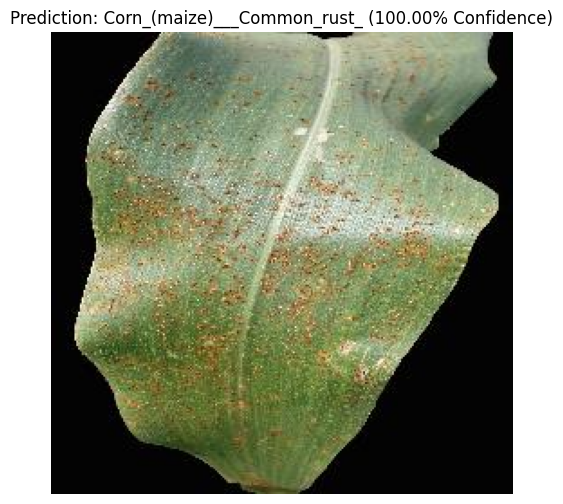

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

custom_image_path = "/content/final_dataset/test/Corn_(maize)___Common_rust_/RS_Rust 1566.JPG" #@param {type:"string"}

if custom_image_path and os.path.exists(custom_image_path):
    predicted_label, confidence = predict_image(custom_image_path)
    print(f"Predicted Label: {predicted_label}")
    print(f"Confidence: {confidence:.2f}%")
    plt.figure(figsize=(6, 6))
    img_display = PILImage.open(custom_image_path)
    plt.imshow(img_display)
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}% Confidence)")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ Invalid image path. Please provide a valid path.")

## 🔧 Step 15: Fine-Tuning (3 Epochs)

> Run this **after** transfer learning is complete (when you're happy with validation accuracy).
>
> This unfreezes the last 20 layers of EfficientNetB0 and trains with a very low learning rate to squeeze out extra accuracy.
>
> Fine-tuning history is also appended to the persistent matrix so graphs stay complete.

In [21]:
# ============================================================
# 🔧 FINE-TUNING — Unfreeze top layers of EfficientNetB0
# ============================================================

FINETUNE_EPOCHS   = 3
FINETUNE_LR       = 1e-5          # much smaller than transfer-learning LR
UNFREEZE_FROM_LAYER = -20         # unfreeze last 20 layers of base_model

FINETUNE_WEIGHTS  = os.path.join(SAVE_DIR, "model_finetuned.weights.h5")
FINETUNE_HIST     = os.path.join(SAVE_DIR, "finetuning_history.json")

# ── Make sure drive is mounted ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Load best transfer-learning weights ───────────────────────
if os.path.exists(WEIGHTS_FILE):
    model.load_weights(WEIGHTS_FILE)
    print(f"✅ Loaded transfer-learning weights from {WEIGHTS_FILE}")
else:
    print("⚠️  No saved weights found. Run training (Step 8) first!")

# ── Unfreeze top layers of base model ─────────────────────────
base_model = model.layers[0]       # EfficientNetB0 is the first layer
base_model.trainable = True

# Freeze all layers except the last UNFREEZE_FROM_LAYER
for layer in base_model.layers[:UNFREEZE_FROM_LAYER]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"🔓 Unfrozen layers in base_model: {unfrozen}")

# ── Recompile with low LR ──────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── Determine initial_epoch for fine-tuning ────────────────────
# Load transfer-learning epoch count so fine-tune epochs continue numbering
if os.path.exists(EPOCH_FILE):
    with open(EPOCH_FILE) as f:
        tl_epochs_done = int(f.read().strip())
else:
    tl_epochs_done = 0

ft_start = tl_epochs_done
ft_end   = ft_start + FINETUNE_EPOCHS
print(f"▶️  Fine-tuning: epochs {ft_start} → {ft_end}")

# ── Fine-tune callbacks ────────────────────────────────────────
ft_checkpoint = ModelCheckpoint(
    FINETUNE_WEIGHTS,
    save_weights_only=True,
    save_freq='epoch',
    verbose=1
)

# ── Run fine-tuning ────────────────────────────────────────────
ft_history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=ft_end,
    initial_epoch=ft_start,
    callbacks=[ft_checkpoint]
)

# ── Append fine-tune metrics to persistent history matrix ──────
with open(HISTORY_FILE, "r") as f:
    all_history = json.load(f)

for key in ["accuracy", "val_accuracy", "loss", "val_loss"]:
    all_history[key].extend(ft_history.history[key])

with open(HISTORY_FILE, "w") as f:
    json.dump(all_history, f)

# ── Save fine-tune history separately too ──────────────────────
with open(FINETUNE_HIST, "w") as f:
    json.dump(ft_history.history, f)

print(f"\n✅ Fine-tuning complete!")
print(f"💾 Fine-tuned weights → {FINETUNE_WEIGHTS}")
print(f"📊 History matrix updated → {HISTORY_FILE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded transfer-learning weights from /content/drive/MyDrive/agrovision_checkpoint/model.weights.h5
🔓 Unfrozen layers in base_model: 20
▶️  Fine-tuning: epochs 8 → 11
Epoch 9/11
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.8525 - loss: 0.4930
Epoch 9: saving model to /content/drive/MyDrive/agrovision_checkpoint/model_finetuned.weights.h5

Epoch 9: finished saving model to /content/drive/MyDrive/agrovision_checkpoint/model_finetuned.weights.h5
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 943s 520ms/step - accuracy: 0.8776 - loss: 0.3979 - val_accuracy: 0.9615 - val_loss: 0.1194
Epoch 10/11
1757/1757 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9132 - loss: 0.2679
Epoch 10: saving model to /content/drive/MyDrive/agrovision_checkpoint/model_finetuned.weights.h5

Epoch 10: finished saving model to /content/drive/MyDrive/agrovision_checkpoint/model_finetuned

## 📈 Step 16: Plot Full History (Transfer Learning + Fine-Tuning)
> Shows the **complete picture** — transfer learning epochs AND fine-tuning epochs in one graph.

📊 Total epochs: 11
   Transfer learning : epochs 1–8
   Fine-tuning       : epochs 9–11


/tmp/ipykernel_3023/3906650472.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/3906650472.py:36: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/3906650472.py:37: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "full_training_curves.png"), dpi=150)
/tmp/ipykernel_3023/3906650472.py:37: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "full_training_curves.png"), dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

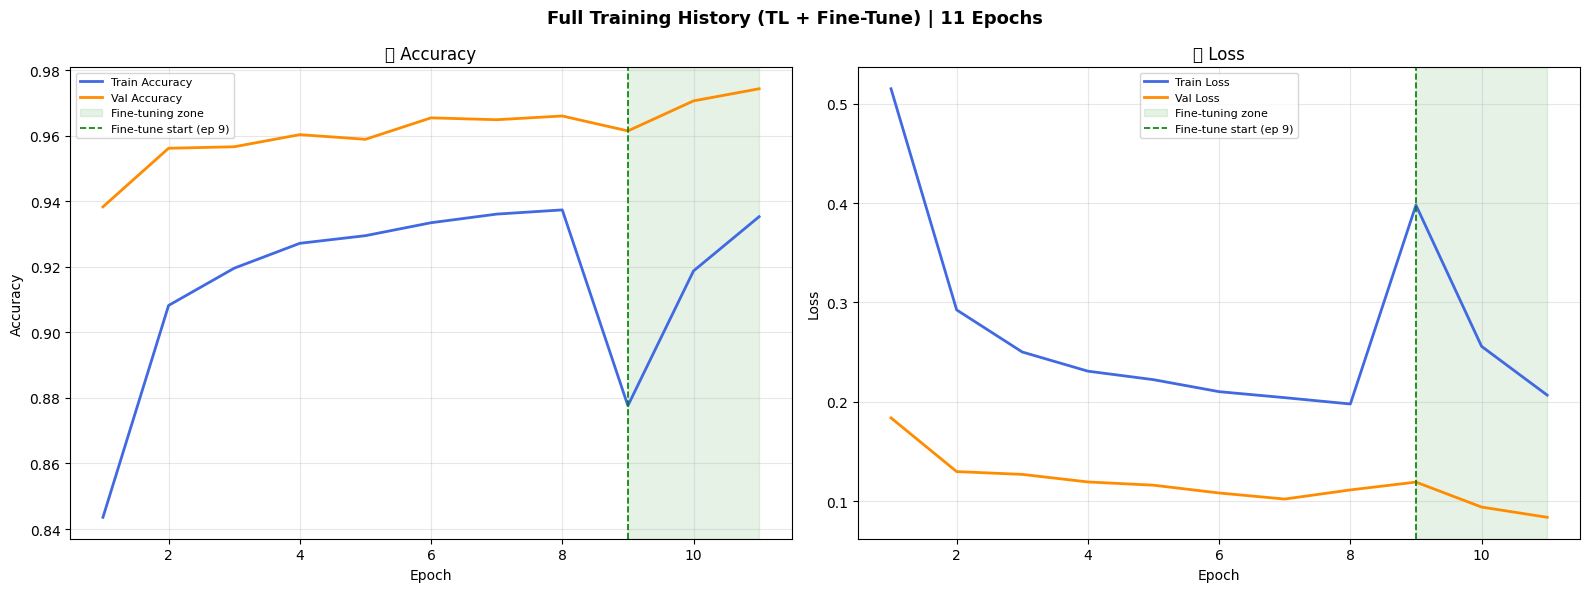

✅ Graph 1 saved → full_training_curves.png


/tmp/ipykernel_3023/3906650472.py:69: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/3906650472.py:69: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3023/3906650472.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "finetune_only_curves.png"), dpi=150)
/tmp/ipykernel_3023/3906650472.py:70: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "finetune_only_curves.png"), dpi=150)


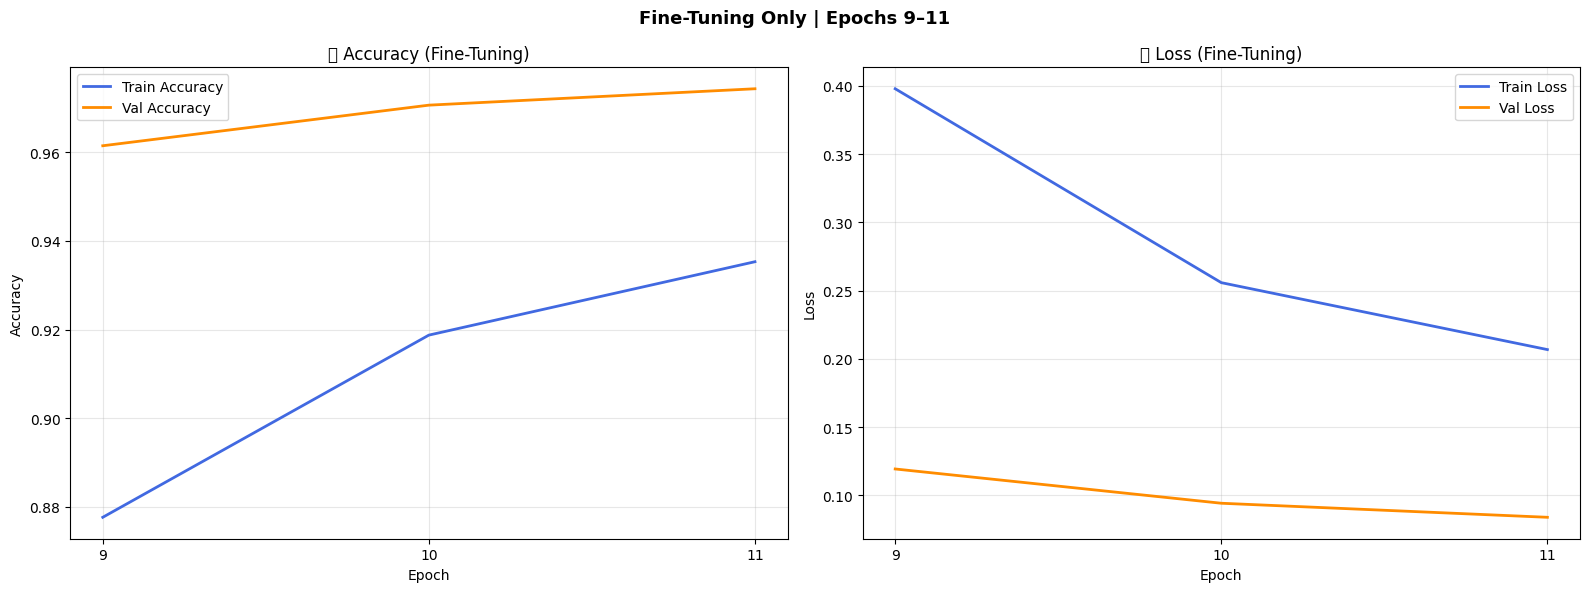

✅ Graph 2 saved → finetune_only_curves.png


In [22]:
# ── Load full accumulated history (TL + fine-tune) ────────────
with open(HISTORY_FILE, "r") as f:
    all_history = json.load(f)

total_epochs_trained = len(all_history['accuracy'])
epoch_range = range(1, total_epochs_trained + 1)

# Determine where fine-tuning started
ft_start_epoch = tl_epochs_done + 1
ft_epoch_range = range(ft_start_epoch, total_epochs_trained + 1)

print(f"📊 Total epochs: {total_epochs_trained}")
print(f"   Transfer learning : epochs 1–{tl_epochs_done}")
print(f"   Fine-tuning       : epochs {ft_start_epoch}–{total_epochs_trained}")

# ── GRAPH 1: Full History (TL + Fine-Tune) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Full Training History (TL + Fine-Tune) | {total_epochs_trained} Epochs",
             fontsize=13, fontweight='bold')

for ax, metric, title, ylabel in [
    (axes[0], ('accuracy', 'val_accuracy'), '📈 Accuracy', 'Accuracy'),
    (axes[1], ('loss', 'val_loss'),         '📉 Loss',     'Loss')
]:
    ax.plot(epoch_range, all_history[metric[0]], label=f'Train {ylabel}', color='royalblue',  linewidth=2)
    ax.plot(epoch_range, all_history[metric[1]], label=f'Val {ylabel}',   color='darkorange', linewidth=2)
    if ft_start_epoch <= total_epochs_trained:
        ax.axvspan(ft_start_epoch, total_epochs_trained, alpha=0.10, color='green', label='Fine-tuning zone')
        ax.axvline(x=ft_start_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Fine-tune start (ep {ft_start_epoch})')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "full_training_curves.png"), dpi=150)
plt.show()
print("✅ Graph 1 saved → full_training_curves.png")

# ── GRAPH 2: Fine-Tuning Only ─────────────────────────────────
ft_acc     = all_history['accuracy'][tl_epochs_done:]
ft_val_acc = all_history['val_accuracy'][tl_epochs_done:]
ft_loss    = all_history['loss'][tl_epochs_done:]
ft_val_loss= all_history['val_loss'][tl_epochs_done:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Fine-Tuning Only | Epochs {ft_start_epoch}–{total_epochs_trained}",
             fontsize=13, fontweight='bold')

axes[0].plot(ft_epoch_range, ft_acc,     label='Train Accuracy', color='royalblue',  linewidth=2)
axes[0].plot(ft_epoch_range, ft_val_acc, label='Val Accuracy',   color='darkorange', linewidth=2)
axes[0].set_title('📈 Accuracy (Fine-Tuning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(list(ft_epoch_range))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ft_epoch_range, ft_loss,     label='Train Loss', color='royalblue',  linewidth=2)
axes[1].plot(ft_epoch_range, ft_val_loss, label='Val Loss',   color='darkorange', linewidth=2)
axes[1].set_title('📉 Loss (Fine-Tuning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(list(ft_epoch_range))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "finetune_only_curves.png"), dpi=150)
plt.show()
print("✅ Graph 2 saved → finetune_only_curves.png")

## 🏆 Step 17: Final Evaluation After Fine-Tuning

In [23]:
print("\n📊 Final Model Evaluation (after fine-tuning)")
print("=" * 45)
loss, acc = model.evaluate(valid_gen, verbose=1)
print(f"\n✅ Validation Accuracy : {acc*100:.2f}%")
print(f"✅ Validation Loss     : {loss:.4f}")


📊 Final Model Evaluation (after fine-tuning)
550/550 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9743 - loss: 0.0840

✅ Validation Accuracy : 97.43%
✅ Validation Loss     : 0.0840


/tmp/ipykernel_3023/3235182369.py:139: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
/tmp/ipykernel_3023/3235182369.py:139: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
/tmp/ipykernel_3023/3235182369.py:139: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
/tmp/ipykernel_3023/3235182369.py:139: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
/tmp/ipykernel_3023/3235182369.py:139: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
/tmp/ipykernel_3023/3235182369.py:139

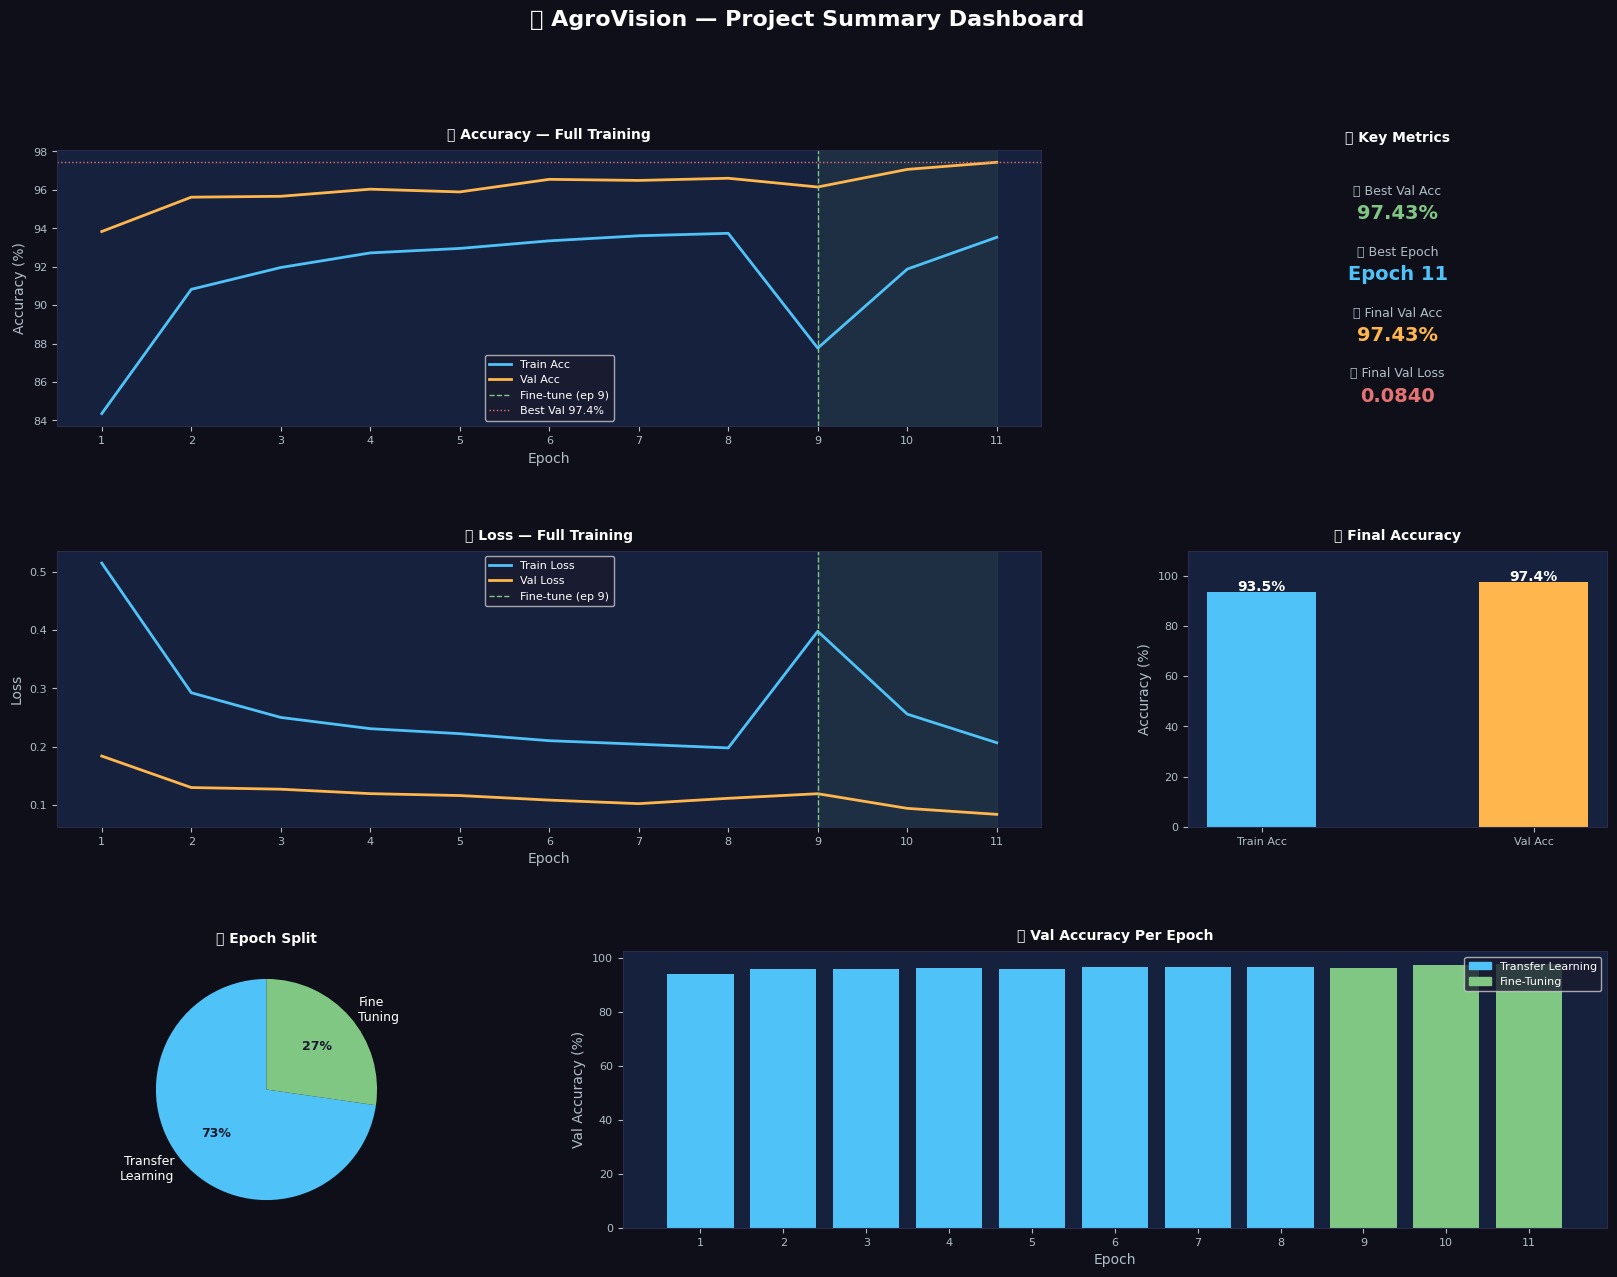

✅ Dashboard saved → project_summary_dashboard.png


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import json

# ── Load history ───────────────────────────────────────────────
with open(HISTORY_FILE, "r") as f:
    all_history = json.load(f)

total_epochs = len(all_history['accuracy'])
ft_start     = tl_epochs_done + 1
epoch_range  = range(1, total_epochs + 1)

# ── Final metrics ──────────────────────────────────────────────
final_train_acc = all_history['accuracy'][-1]   * 100
final_val_acc   = all_history['val_accuracy'][-1] * 100
final_train_loss= all_history['loss'][-1]
final_val_loss  = all_history['val_loss'][-1]
best_val_acc    = max(all_history['val_accuracy']) * 100
best_epoch      = all_history['val_accuracy'].index(max(all_history['val_accuracy'])) + 1

# ── Layout ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

BLUE   = '#4fc3f7'
ORANGE = '#ffb74d'
GREEN  = '#81c784'
RED    = '#e57373'
WHITE  = '#ffffff'
GRAY   = '#b0bec5'
BG     = '#1a1a2e'
CARD   = '#16213e'

def style_ax(ax, title):
    ax.set_facecolor(CARD)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.set_title(title, color=WHITE, fontsize=10, fontweight='bold', pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a4a')

# ── 1. Accuracy curve (full) ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epoch_range, [v*100 for v in all_history['accuracy']],
         color=BLUE, linewidth=2, label='Train Acc')
ax1.plot(epoch_range, [v*100 for v in all_history['val_accuracy']],
         color=ORANGE, linewidth=2, label='Val Acc')
ax1.axvspan(ft_start, total_epochs, alpha=0.08, color=GREEN)
ax1.axvline(x=ft_start, color=GREEN, linestyle='--', linewidth=1, label=f'Fine-tune (ep {ft_start})')
ax1.axhline(y=best_val_acc, color=RED, linestyle=':', linewidth=1, label=f'Best Val {best_val_acc:.1f}%')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(list(epoch_range))
ax1.legend(fontsize=8, facecolor=BG, labelcolor=WHITE)
style_ax(ax1, '📈 Accuracy — Full Training')

# ── 2. Loss curve (full) ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(epoch_range, all_history['loss'],
         color=BLUE, linewidth=2, label='Train Loss')
ax2.plot(epoch_range, all_history['val_loss'],
         color=ORANGE, linewidth=2, label='Val Loss')
ax2.axvspan(ft_start, total_epochs, alpha=0.08, color=GREEN)
ax2.axvline(x=ft_start, color=GREEN, linestyle='--', linewidth=1, label=f'Fine-tune (ep {ft_start})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_xticks(list(epoch_range))
ax2.legend(fontsize=8, facecolor=BG, labelcolor=WHITE)
style_ax(ax2, '📉 Loss — Full Training')

# ── 3. Metric cards ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(CARD)
ax3.axis('off')
cards = [
    ("🏆 Best Val Acc",   f"{best_val_acc:.2f}%",    GREEN),
    ("📍 Best Epoch",     f"Epoch {best_epoch}",      BLUE),
    ("🎯 Final Val Acc",  f"{final_val_acc:.2f}%",   ORANGE),
    ("📉 Final Val Loss", f"{final_val_loss:.4f}",    RED),
]
for i, (label, value, color) in enumerate(cards):
    y = 0.85 - i * 0.22
    ax3.text(0.5, y,       label, ha='center', va='center', color=GRAY,  fontsize=9,  transform=ax3.transAxes)
    ax3.text(0.5, y - 0.08, value, ha='center', va='center', color=color, fontsize=14, fontweight='bold', transform=ax3.transAxes)
ax3.set_title('📊 Key Metrics', color=WHITE, fontsize=10, fontweight='bold')

# ── 4. Train vs Val accuracy bar ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
bars = ax4.bar(['Train Acc', 'Val Acc'],
               [final_train_acc, final_val_acc],
               color=[BLUE, ORANGE], width=0.4, edgecolor='none')
for bar, val in zip(bars, [final_train_acc, final_val_acc]):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', color=WHITE, fontsize=10, fontweight='bold')
ax4.set_ylim(0, 110)
ax4.set_ylabel('Accuracy (%)')
style_ax(ax4, '🎯 Final Accuracy')

# ── 5. Epoch breakdown pie ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
tl_eps = ft_start - 1
ft_eps = total_epochs - tl_eps
wedges, texts, autotexts = ax5.pie(
    [tl_eps, ft_eps],
    labels=['Transfer\nLearning', 'Fine\nTuning'],
    colors=[BLUE, GREEN],
    autopct='%1.0f%%',
    startangle=90,
    textprops={'color': WHITE, 'fontsize': 9}
)
for at in autotexts:
    at.set_color(BG)
    at.set_fontweight('bold')
ax5.set_facecolor(CARD)
ax5.set_title('🔁 Epoch Split', color=WHITE, fontsize=10, fontweight='bold')

# ── 6. Per-epoch val accuracy bar ────────────────────────────
ax6 = fig.add_subplot(gs[2, 1:])
colors_bar = [GREEN if i >= tl_eps else BLUE for i in range(total_epochs)]
ax6.bar(list(epoch_range),
        [v*100 for v in all_history['val_accuracy']],
        color=colors_bar, edgecolor='none')
ax6.set_xlabel('Epoch')
ax6.set_ylabel('Val Accuracy (%)')
ax6.set_xticks(list(epoch_range))
blue_patch  = mpatches.Patch(color=BLUE,  label='Transfer Learning')
green_patch = mpatches.Patch(color=GREEN, label='Fine-Tuning')
ax6.legend(handles=[blue_patch, green_patch], fontsize=8,
           facecolor=BG, labelcolor=WHITE)
style_ax(ax6, '📊 Val Accuracy Per Epoch')

# ── Title ─────────────────────────────────────────────────────
fig.suptitle('🌿 AgroVision — Project Summary Dashboard',
             fontsize=16, fontweight='bold', color=WHITE, y=0.98)

plt.savefig(os.path.join(SAVE_DIR, "project_summary_dashboard.png"),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved → project_summary_dashboard.png")